# Baseline Model: Logistic Regression

This notebook builds a simple baseline model for the `Dropout` target using `cleaned_df.csv`.
The trained model is saved inside the `models` folder so it can be reused later.

In [6]:
pip install joblib pandas matplotlib seaborn scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: C:\Users\ADMIN\Desktop\Pyspark\sparkenv\Scripts\python.exe -m pip install --upgrade pip


In [7]:
# Importing the libraries we need
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

random_state = 42

In [8]:
# Load the cleaned dataset
data_path = Path('data') / 'cleaned_df.csv'
df = pd.read_csv(data_path)

print('Dataset shape:', df.shape)
display(df.head())

print('Target distribution:')
print(df['Dropout'].value_counts(normalize=True).sort_index())

Dataset shape: (9500, 18)


,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Year of study,Department,Parental_Education,Dropout
0,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,1,Arts,High School,0
1,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,3,Engineering,Bachelor,1
2,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,1,Arts,Master,0
3,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,4,Business,Bachelor,0
4,20.5,1,25000.0,1,4.11,89.1,2,47.1,0,1,6.0,2.52,2.72,2.69,3,Business,NaN,0


Target distribution:
Dropout
0    0.764105
1    0.235895
Name: proportion, dtype: float64


In [9]:
# Separate features and target
X = df.drop(columns=['Dropout'])
y = df['Dropout']

# Split the data so we can measure performance on unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)

# Find numeric and categorical columns automatically
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Year of study']
Categorical features: ['Department', 'Parental_Education']


In [10]:
# Build the preprocessing steps
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Create the baseline Logistic Regression model
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, solver='liblinear', random_state=random_state))
])

baseline_model.fit(X_train, y_train)
print('Model training completed.')

Model training completed.


Accuracy: 0.8105

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1452
           1       0.66      0.40      0.50       448

    accuracy                           0.81      1900
   macro avg       0.75      0.67      0.69      1900
weighted avg       0.79      0.81      0.79      1900



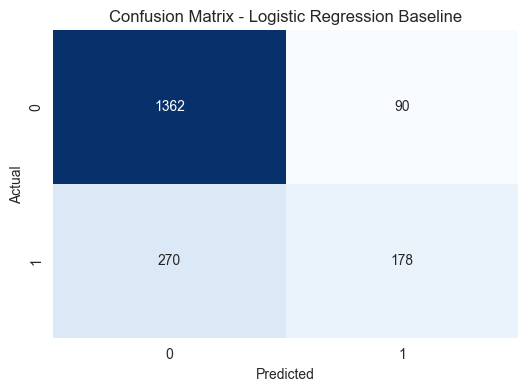

In [11]:
# Evaluate the model on the test set
y_pred = baseline_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print()
print('Classification report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Logistic Regression Baseline')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
# Save the trained model inside the models folder
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

model_path = models_dir / 'baseline_logistic_regression.pkl'
joblib.dump(baseline_model, model_path)

print(f'Model saved to: {model_path}')

Model saved to: models\baseline_logistic_regression.pkl
